TASK 1 (MILESTONE 1)

In [ ]:
#mount in google drive
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
files.upload()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"subhasrinm","key":"0bee4109e772be270fdbb96fd78f961d"}'}

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API credentials configured")


Kaggle API credentials configured


In [ ]:

!kaggle competitions download -c dog-breed-identification -p /content/drive/MyDrive/dog_breed_dataset
print("Dataset downloaded to Google Drive")


 99% 683M/691M [00:04<00:00, 181MB/s]
100% 691M/691M [00:05<00:00, 136MB/s]
Dataset downloaded to Google Drive


In [ ]:

import zipfile, os

zip_path = '/content/drive/MyDrive/dog_breed_dataset.zip'
src_dir = '/content/drive/MyDrive/dog_breed_dataset'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(src_dir):
        for file in files:
            full_path = os.path.join(root, file)
            # Preserve folder structure within the zip
            arcname = os.path.relpath(full_path, src_dir)
            zipf.write(full_path, arcname=arcname)

print("Zipped dataset saved at:", zip_path)


Zipped dataset saved at: /content/drive/MyDrive/dog_breed_dataset.zip


In [ ]:
# unzip the file
import zipfile
import os
from tqdm import tqdm  # progress bar

zip_path = "/content/drive/MyDrive/dog_breed_dataset_extracted/dog-breed-identification.zip"
extract_path = "/content/drive/MyDrive/dog_breed_dataset_extracted/unzipped"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()   # all files inside zip
    for file in tqdm(file_list, desc="Unzipping files", unit="file"):
        zip_ref.extract(file, extract_path)

print("✅ Unzipping completed! Files extracted to:", extract_path)



Unzipping files: 100%|██████████| 20581/20581 [03:48<00:00, 90.18file/s]

✅ Unzipping completed! Files extracted to: /content/drive/MyDrive/dog_breed_dataset_extracted/unzipped


In [ ]:
print("Contents:", os.listdir(extract_path))


Contents: ['labels.csv', 'sample_submission.csv', 'test', 'train']


In [ ]:
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')
label_file = os.path.join(extract_path, 'labels.csv')

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))
print("Labels.csv exists:", os.path.exists(label_file))


Train folder exists: True
Test folder exists: True
Labels.csv exists: True


In [ ]:
#print the first 30 sample data

print("Sample train images (30):")
print(os.listdir(train_dir)[:30])

import pandas as pd
labels_df = pd.read_csv(label_file)
print("\nLabels file (30 rows):")
print(labels_df.head(30))


Sample train images (30):
['000bec180eb18c7604dcecc8fe0dba07.jpg', '001513dfcb2ffafc82cccf4d8bbaba97.jpg', '001cdf01b096e06d78e9e5112d419397.jpg', '00214f311d5d2247d5dfe4fe24b2303d.jpg', '0021f9ceb3235effd7fcde7f7538ed62.jpg', '002211c81b498ef88e1b40b9abf84e1d.jpg', '00290d3e1fdd27226ba27a8ce248ce85.jpg', '002a283a315af96eaea0e28e7163b21b.jpg', '003df8b8a8b05244b1d920bb6cf451f9.jpg', '0042188c895a2f14ef64a918ed9c7b64.jpg', '004396df1acd0f1247b740ca2b14616e.jpg', '0067dc3eab0b3c3ef0439477624d85d6.jpg', '00693b8bc2470375cc744a6391d397ec.jpg', '006cc3ddb9dc1bd827479569fcdc52dc.jpg', '0075dc49dab4024d12fafe67074d8a81.jpg', '00792e341f3c6eb33663e415d0715370.jpg', '007b5a16db9d9ff9d7ad39982703e429.jpg', '007b8a07882822475a4ce6581e70b1f8.jpg', '007ff9a78eba2aebb558afea3a51c469.jpg', '008887054b18ba3c7601792b6a453cc3.jpg', '008b1271ed1addaccf93783b39deab45.jpg', '008ba178d6dfc1a583617470d19c1673.jpg', '009509be3ca7cce0ff9e37c8b09b1125.jpg', '0097c6242c6f3071762d9f85c3ef1b2f.jpg', '00a338a92e4e

## Task 2 (20/08/25)

In [ ]:
# Step 1: Install Hugging Face datasets
!pip install datasets


In [ ]:
# Step 2: Imports
from datasets import load_dataset
import matplotlib.pyplot as plt

In [ ]:
# Step 3: Load the Dog Breed Classification dataset
dataset = load_dataset("Saugatkafley/dog-breed-classification")
print(dataset)  # structure overview


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/513 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10222 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 10222
    })
})


In [ ]:
# Step 4: Helper to read label key safely (some datasets use 'label' vs 'labels')
def get_label(sample):
    if 'labels' in sample:
        return sample['labels']
    if 'label' in sample:
        return sample['label']
    if 'breed' in sample:
        return sample['breed']
    return "Unknown"

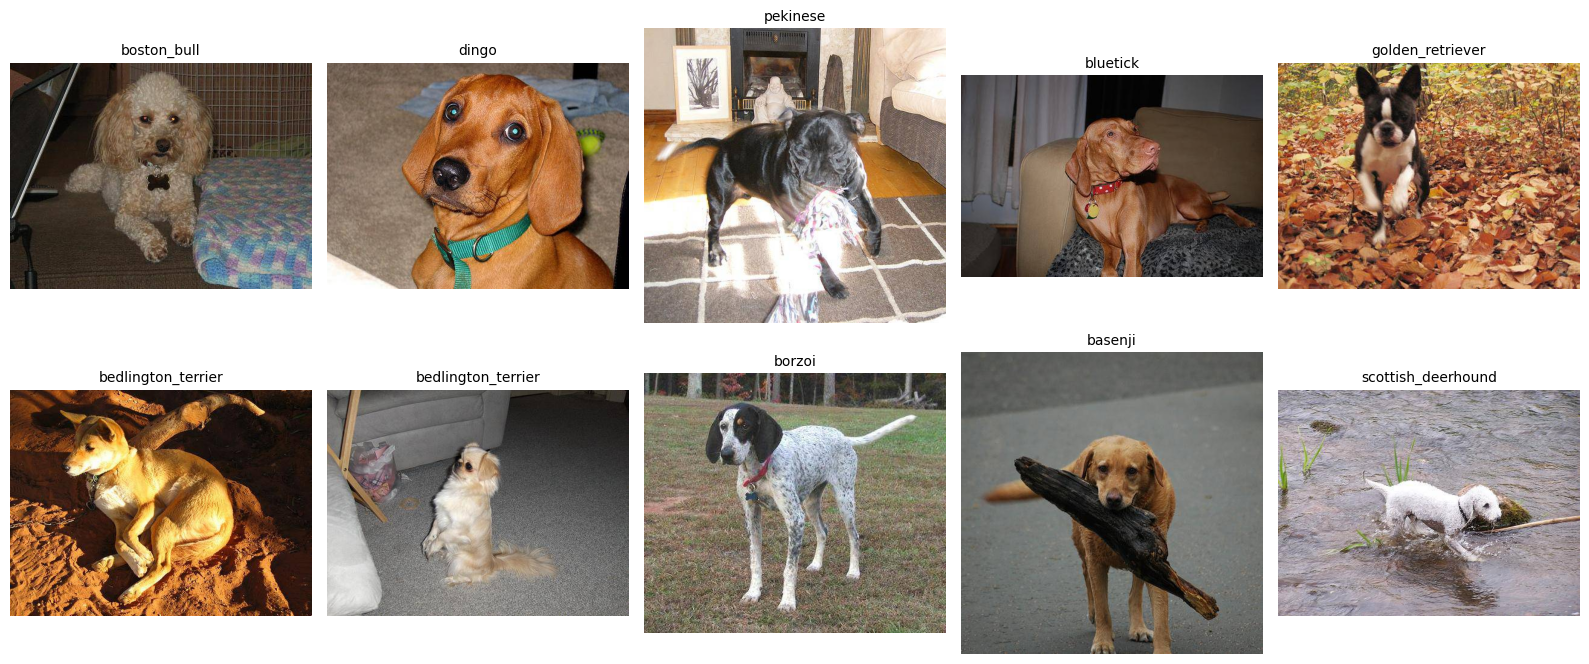

In [ ]:
# Step 5: Show first 10 images in a 2x5 grid
plt.figure(figsize=(16, 7))  # big enough for 10 images

for i in range(10):
    sample = dataset['train'][i]
    img = sample['image']       # PIL Image (usually)
    label = get_label(sample)

    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(img)
    ax.set_title(f"{label}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

# ** TASK 3 (PIXEL)-21/08/25**



In [ ]:
!pip install Pillow

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import time

def get_image_stats(folder):
    start_time = time.time()   # start timer

    files = os.listdir(folder)
    widths, heights = [], []

    for fname in tqdm(files, desc=f"Processing {folder}", unit="img"):
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception as e:
            print(f"❌ Error with file {fname} -> {e}")
            continue

    end_time = time.time()   # end timer
    elapsed = end_time - start_time

    return {
        "count": len(widths),
        "min_width": int(np.min(widths)) if widths else None,
        "max_width": int(np.max(widths)) if widths else None,
        "avg_width": float(np.mean(widths)) if widths else None,
        "min_height": int(np.min(heights)) if heights else None,
        "max_height": int(np.max(heights)) if heights else None,
        "avg_height": float(np.mean(heights)) if heights else None,
        "time_taken_sec": round(elapsed, 2)
    }
    # ✅ Define dataset paths first
train_dir = "/content/drive/MyDrive/dog_breed_dataset_extracted/unzipped/train"
test_dir  = "/content/drive/MyDrive/dog_breed_dataset_extracted/unzipped/test"

# ✅ Run for full train & test
train_stats = get_image_stats(train_dir)
test_stats  = get_image_stats(test_dir)

print("\n📊 Train Stats:", train_stats)
print("\n📊 Test Stats:", test_stats)


Processing /content/drive/MyDrive/dog_breed_dataset_extracted/unzipped/train: 100%|██████████| 10222/10222 [01:29<00:00, 113.59img/s]
Processing /content/drive/MyDrive/dog_breed_dataset_extracted/unzipped/test: 100%|██████████| 10357/10357 [01:33<00:00, 111.23img/s]


📊 Train Stats: {'count': 10222, 'min_width': 97, 'max_width': 3264, 'avg_width': 443.33153981608297, 'min_height': 102, 'max_height': 2562, 'avg_height': 386.74721189591077, 'time_taken_sec': 90.25}

📊 Test Stats: {'count': 10357, 'min_width': 100, 'max_width': 2592, 'avg_width': 441.7647967558173, 'min_height': 100, 'max_height': 2560, 'avg_height': 385.0057931833542, 'time_taken_sec': 97.29}


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

# Function to collect dimensions into dataframe
def collect_image_data(folder, dataset_name):
    data = []
    files = os.listdir(folder)

    for fname in tqdm(files, desc=f"Processing {dataset_name}", unit="img"):
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                w, h = img.size
                data.append({"dataset": dataset_name, "width": w, "height": h})
        except:
            continue
    return pd.DataFrame(data)

# Collect train + test data
train_df = collect_image_data(train_dir, "train")
test_df  = collect_image_data(test_dir, "test")

# Combine into one dataframe
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()


Processing test: 100%|██████████| 10357/10357 [01:43<00:00, 100.01img/s]


,dataset,width,height
0,train,500,420
1,train,500,333
2,train,500,375
3,train,324,260
4,train,480,360


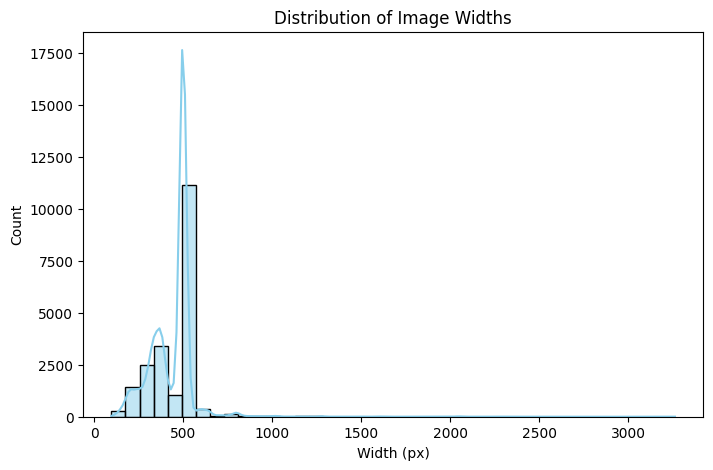

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Image Widths
plt.figure(figsize=(8,5))
sns.histplot(df['width'], bins=40, kde=True, color="skyblue")
plt.title("Distribution of Image Widths")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.show()




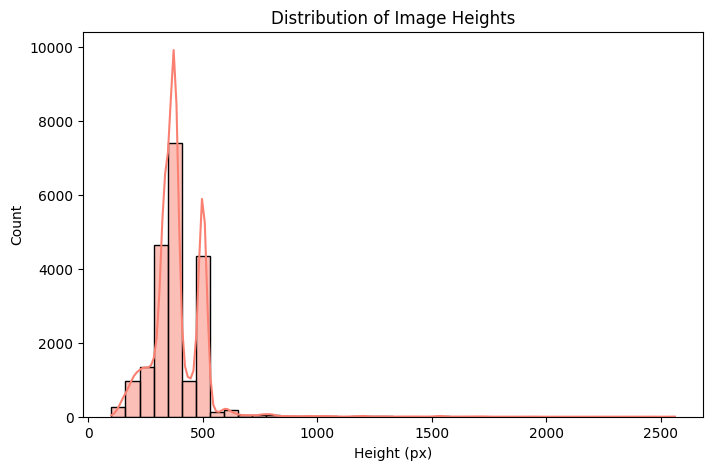

In [ ]:
# 2. Distribution of Image Heights
plt.figure(figsize=(8,5))
sns.histplot(df['height'], bins=40, kde=True, color="salmon")
plt.title("Distribution of Image Heights")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.show()



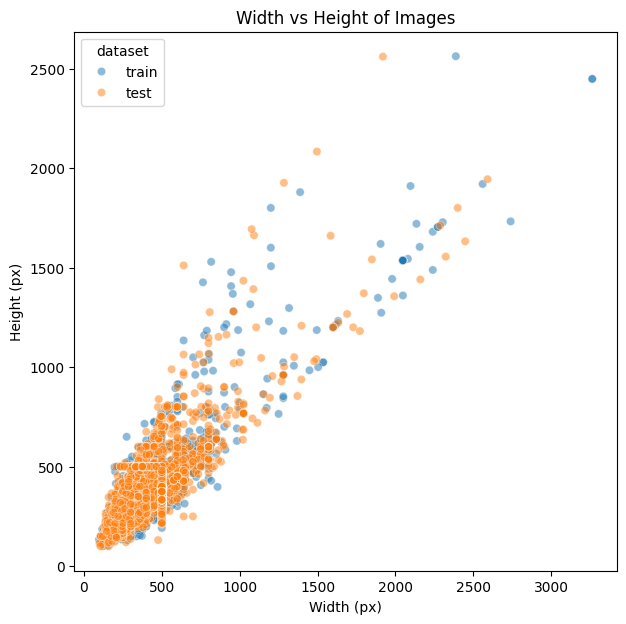

In [ ]:
# 3. Width vs Height Scatter Plot
plt.figure(figsize=(7,7))
sns.scatterplot(data=df, x="width", y="height", hue="dataset", alpha=0.5)
plt.title("Width vs Height of Images")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.show()


/tmp/ipython-input-532809379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dataset", y="width", palette="Set2")


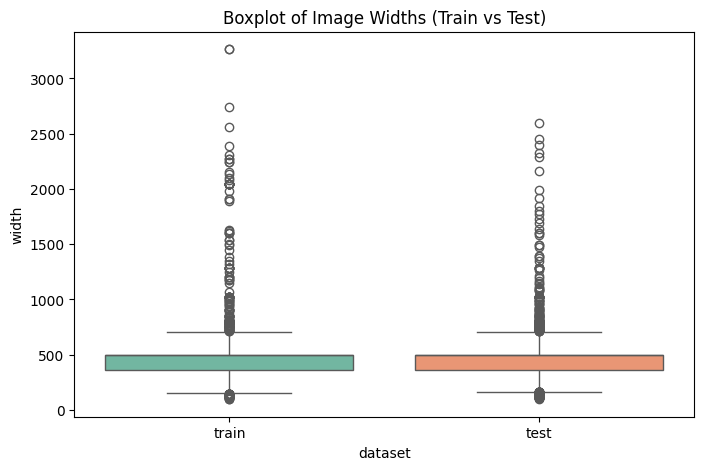

In [ ]:

# 4. Boxplot of Widths by Dataset
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="dataset", y="width", palette="Set2")
plt.title("Boxplot of Image Widths (Train vs Test)")
plt.show()


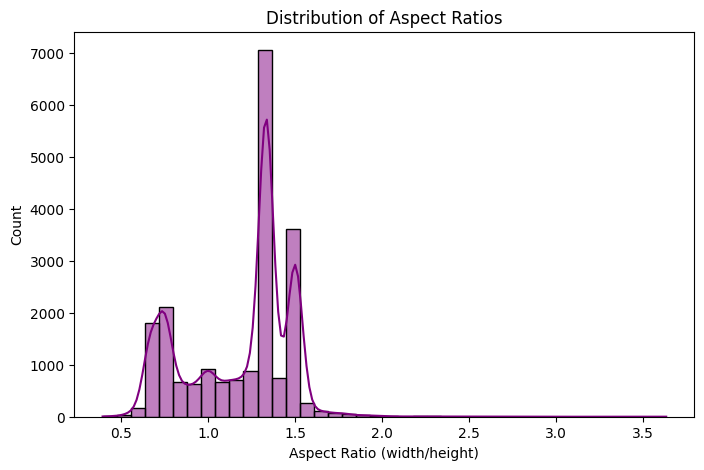

In [ ]:
# 5. Aspect Ratio Distribution
df["aspect_ratio"] = df["width"] / df["height"]
plt.figure(figsize=(8,5))
sns.histplot(df["aspect_ratio"], bins=40, kde=True, color="purple")
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio (width/height)")
plt.ylabel("Count")
plt.show()

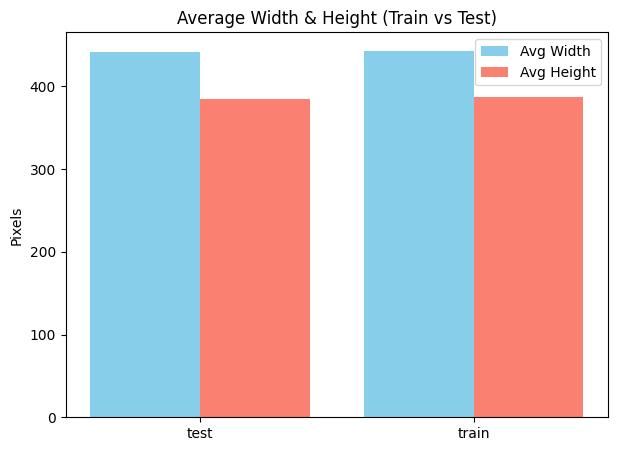

In [ ]:
# ✅ Average size stats
avg_stats = df.groupby("dataset")[["width", "height"]].mean().reset_index()

# ✅ Plot bar chart
plt.figure(figsize=(7,5))
x = range(len(avg_stats))

plt.bar(x, avg_stats["width"], width=0.4, label="Avg Width", color="skyblue")
plt.bar([i+0.4 for i in x], avg_stats["height"], width=0.4, label="Avg Height", color="salmon")

plt.xticks([i+0.2 for i in x], avg_stats["dataset"])
plt.ylabel("Pixels")
plt.title("Average Width & Height (Train vs Test)")
plt.legend()
plt.show()

✅ Labels Loaded: (10222, 2)
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


/tmp/ipython-input-3008205097.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=breed_counts.head(120).index, y=breed_counts.head(120).values, palette="viridis")


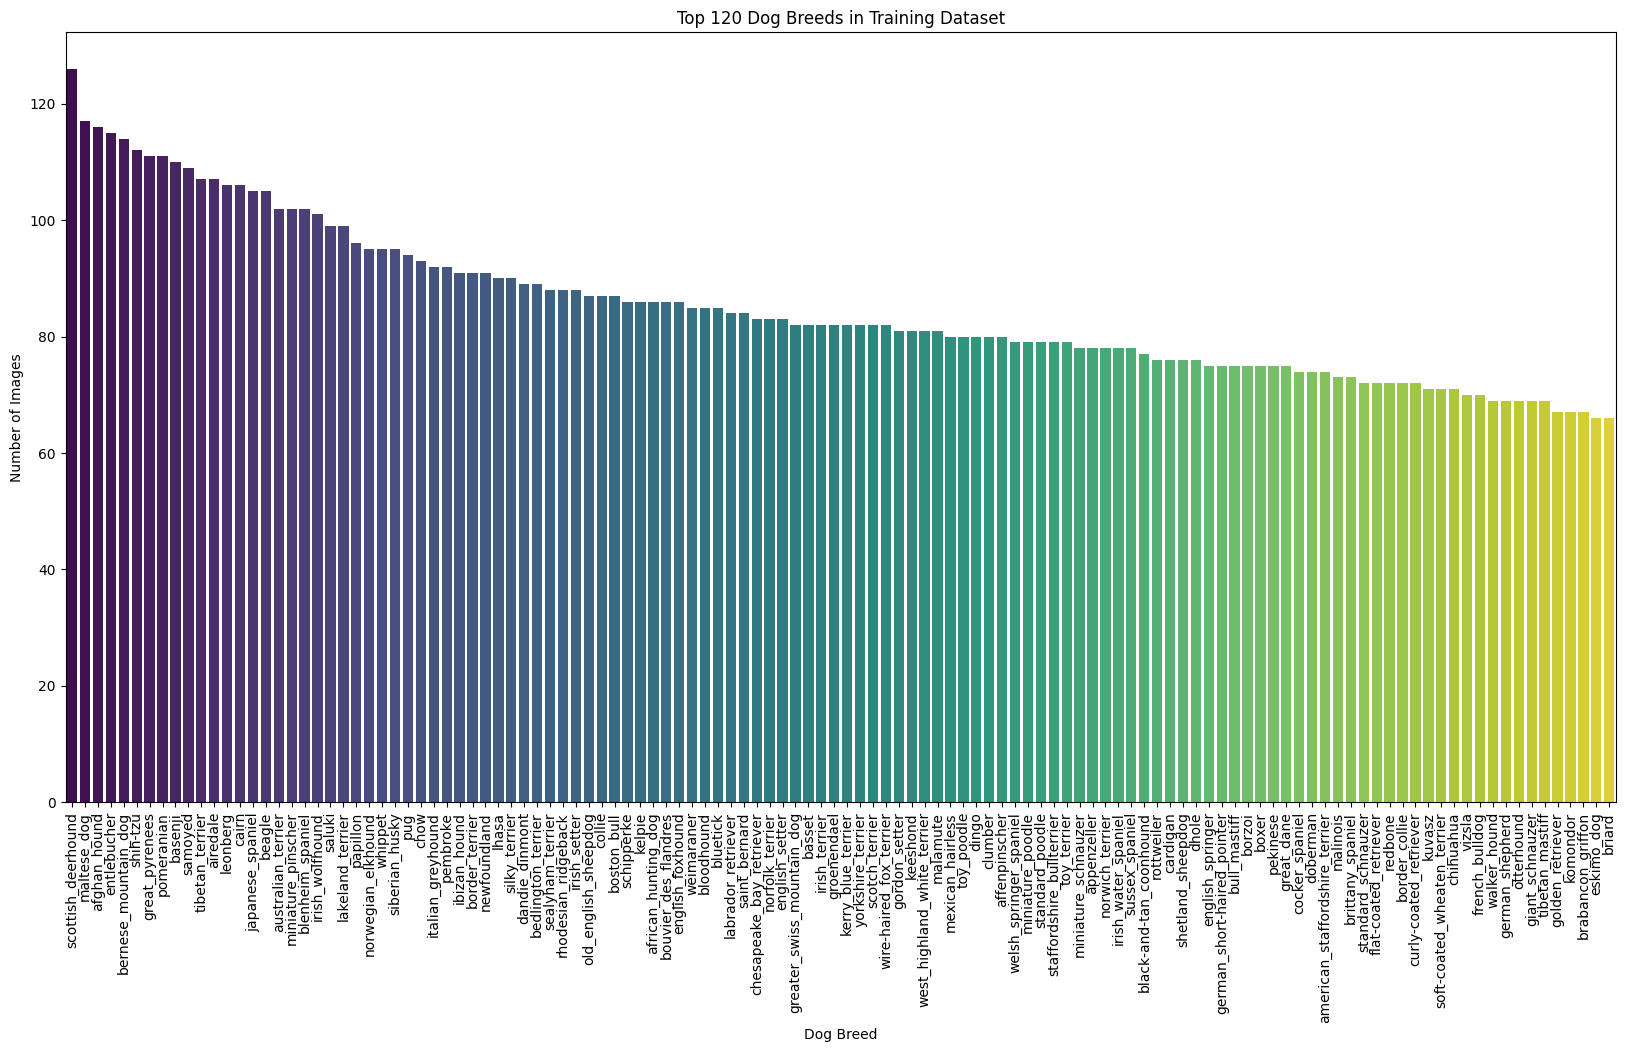

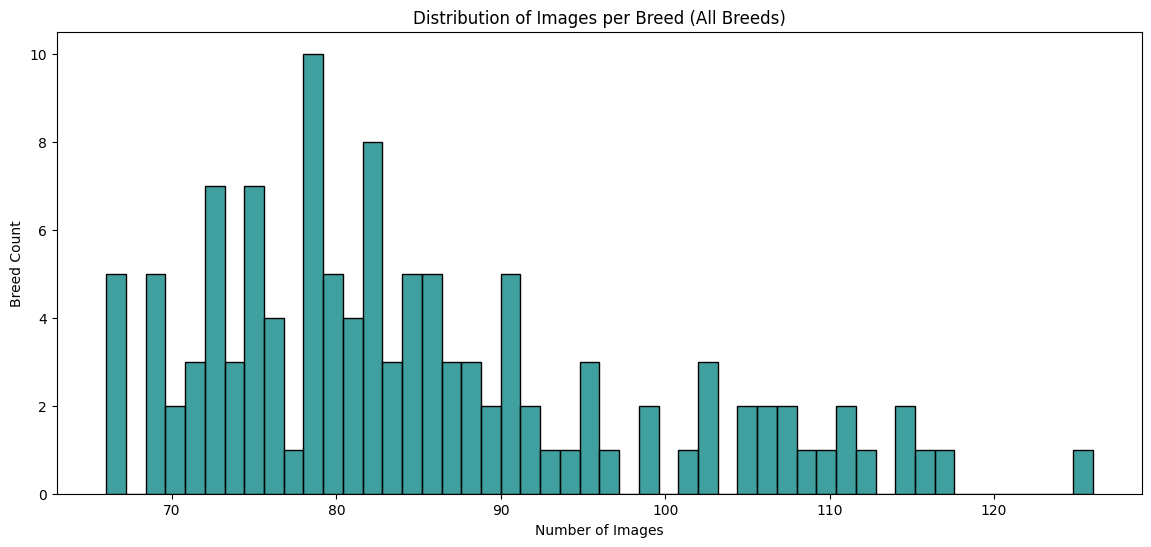

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Path to labels.csv
labels_path = "/content/drive/MyDrive/dog_breed_dataset_extracted/unzipped/labels.csv"

# Load CSV
labels_df = pd.read_csv(labels_path)
print("✅ Labels Loaded:", labels_df.shape)
print(labels_df.head())

# ---------- Count images per breed ----------
breed_counts = labels_df["breed"].value_counts()

# ---------- Plot Top 120 breeds ----------
plt.figure(figsize=(20,10))
sns.barplot(x=breed_counts.head(120).index, y=breed_counts.head(120).values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 120 Dog Breeds in Training Dataset")
plt.xlabel("Dog Breed")
plt.ylabel("Number of Images")
plt.show()

# ---------- Plot Overall Distribution ----------
plt.figure(figsize=(14,6))
sns.histplot(breed_counts, bins=50, kde=False, color="teal")
plt.title("Distribution of Images per Breed (All Breeds)")
plt.xlabel("Number of Images")
plt.ylabel("Breed Count")
plt.show()
